In [1]:
import tensorflow

Importing Face Mask Dataset

In [4]:
# Re-attempting extraction to confirm successful re-upload of dataset.zip
from zipfile import ZipFile
import os

zip_file_name = '/content/dataset.zip'

if not os.path.exists(zip_file_name):
    print(f"Error: The file '{zip_file_name}' was not found. Please ensure it has been uploaded to the specified path.")
else:
    try:
        with ZipFile(zip_file_name,'r') as zip_ref:
            zip_ref.extractall()
            print(f'The dataset is extracted from {zip_file_name}.')

        # The Kaggle dataset extracts into a folder structure like 'dataset/data/...'
        # We need to move the 'data' directory to the top level ('/content/')
        extracted_data_path = 'dataset/data'
        target_data_path = 'data'

        if os.path.exists(extracted_data_path):
            # Remove existing 'data' directory if it's from a previous extraction
            if os.path.exists(target_data_path):
                import shutil
                shutil.rmtree(target_data_path)
                print(f'Removed existing {target_data_path} directory.')

            os.rename(extracted_data_path, target_data_path)
            print(f'Moved "{extracted_data_path}" to "{target_data_path}" for use by the rest of the notebook.')
        elif os.path.exists(target_data_path):
            print(f'"data" directory already exists and is ready for use.')
        else:
            print('Could not find "dataset/data" or "data" directory after extraction. Please verify the structure of your zip file.')
    except Exception as e:
        print(f"Error during extraction: {e}. The file might still be corrupted or not a valid zip file.")

The dataset is extracted from /content/dataset.zip.
Moved "dataset/data" to "data" for use by the rest of the notebook.


In [5]:
!ls

data  dataset  dataset.zip  sample_data  with_mask_3.jpg  without_mask_3.jpg


**Importing the Dependencies**

In [6]:
import os
import numpy as np
import tensorflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_207.jpg', 'with_mask_2721.jpg', 'with_mask_2776.jpg', 'with_mask_2042.jpg', 'with_mask_3556.jpg']
['with_mask_2018.jpg', 'with_mask_1796.jpg', 'with_mask_70.jpg', 'with_mask_3648.jpg', 'with_mask_9.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2049.jpg', 'without_mask_1777.jpg', 'without_mask_108.jpg', 'without_mask_429.jpg', 'without_mask_891.jpg']
['without_mask_1832.jpg', 'without_mask_3439.jpg', 'without_mask_576.jpg', 'without_mask_3072.jpg', 'without_mask_2492.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Creating Labels for the two class of Images**

with mask  -->  1

without mask  -->  0

In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

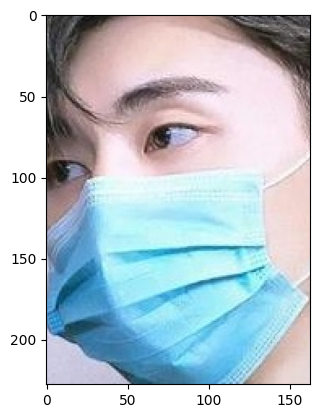

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

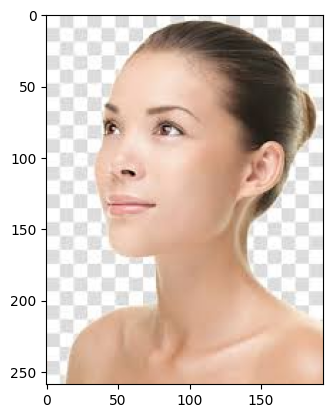

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[ 24,  32,  43],
        [ 27,  35,  46],
        [ 34,  42,  53],
        ...,
        [ 50,  55,  73],
        [ 50,  57,  72],
        [ 50,  56,  72]],

       [[ 27,  35,  46],
        [ 29,  37,  48],
        [ 34,  42,  53],
        ...,
        [ 52,  57,  75],
        [ 53,  59,  75],
        [ 53,  60,  75]],

       [[ 32,  40,  51],
        [ 32,  40,  51],
        [ 32,  40,  51],
        ...,
        [ 56,  61,  79],
        [ 58,  63,  80],
        [ 58,  65,  80]],

       ...,

       [[  5,   8,  15],
        [  7,  10,  17],
        [ 10,  13,  20],
        ...,
        [188, 186, 203],
        [191, 188, 205],
        [193, 190, 206]],

       [[ 11,  14,  21],
        [ 10,  13,  20],
        [  8,  10,  18],
        ...,
        [192, 189, 206],
        [191, 188, 204],
        [192, 188, 203]],

       [[ 15,  18,  25],
        [ 12,  15,  22],
        [  7,   9,  17],
        ...,
        [194, 190, 207],
        [191, 188, 203],
        [191, 187, 201]]], dtype=uint8)
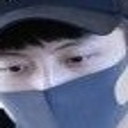

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)

numpy.ndarray

In [24]:
type(Y)

numpy.ndarray

In [25]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [26]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Split**

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [29]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[189, 184, 181],
        [232, 227, 224],
        [227, 222, 219],
        ...,
        [110, 102,  91],
        [110, 102,  91],
        [110, 102,  91]],

       [[193, 188, 185],
        [229, 224, 221],
        [225, 220, 217],
        ...,
        [111, 103,  92],
        [111, 103,  92],
        [111, 103,  92]],

       [[213, 208, 205],
        [228, 223, 220],
        [223, 218, 215],
        ...,
        [112, 104,  93],
        [112, 104,  93],
        [112, 104,  93]],

       ...,

       [[116, 102,  65],
        [134, 120,  83],
        [145, 131,  95],
        ...,
        [132, 124, 113],
        [131, 123, 112],
        [131, 123, 112]],

       [[119, 105,  66],
        [136, 122,  83],
        [143, 129,  92],
        ...,
        [132, 124, 113],
        [131, 123, 112],
        [131, 123, 112]],

       [[119, 105,  66],
        [136, 122,  83],
        [142, 128,  91],
        ...,
        [132, 124, 113],
        [131, 123, 112],
        [131, 123, 112]]], dtype=uint8)
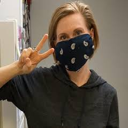

In [30]:
X_train[0]

In [31]:
X_train_scaled[0]

array([[[0.74117647, 0.72156863, 0.70980392],
        [0.90980392, 0.89019608, 0.87843137],
        [0.89019608, 0.87058824, 0.85882353],
        ...,
        [0.43137255, 0.4       , 0.35686275],
        [0.43137255, 0.4       , 0.35686275],
        [0.43137255, 0.4       , 0.35686275]],

       [[0.75686275, 0.7372549 , 0.7254902 ],
        [0.89803922, 0.87843137, 0.86666667],
        [0.88235294, 0.8627451 , 0.85098039],
        ...,
        [0.43529412, 0.40392157, 0.36078431],
        [0.43529412, 0.40392157, 0.36078431],
        [0.43529412, 0.40392157, 0.36078431]],

       [[0.83529412, 0.81568627, 0.80392157],
        [0.89411765, 0.8745098 , 0.8627451 ],
        [0.8745098 , 0.85490196, 0.84313725],
        ...,
        [0.43921569, 0.40784314, 0.36470588],
        [0.43921569, 0.40784314, 0.36470588],
        [0.43921569, 0.40784314, 0.36470588]],

       ...,

       [[0.45490196, 0.4       , 0.25490196],
        [0.5254902 , 0.47058824, 0.3254902 ],
        [0.56862745, 0

**Building a Convolutional Neural Networks (CNN)**

In [32]:
import tensorflow as tf
from tensorflow import keras

In [33]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [35]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - acc: 0.8157 - loss: 0.4121 - val_acc: 0.9041 - val_loss: 0.2104
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8896 - loss: 0.2854 - val_acc: 0.9223 - val_loss: 0.2013
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9143 - loss: 0.2311 - val_acc: 0.9174 - val_loss: 0.1859
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9290 - loss: 0.1808 - val_acc: 0.9372 - val_loss: 0.1716
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9373 - loss: 0.1673 - val_acc: 0.9421 - val_loss: 0.1538
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9520 - loss: 0.1390 - val_acc: 0.9273 - val_loss: 0.1820
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9531 - loss: 0.1321 - val_acc: 0.9306 - val_loss: 0.1628
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9638 - loss: 0.1018 - val_acc: 0.9306 - val_loss: 0.1626
Epoch 9/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms

**Model Evaluation**

In [36]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9451 - loss: 0.1966
Test Accuracy = 0.9450694918632507


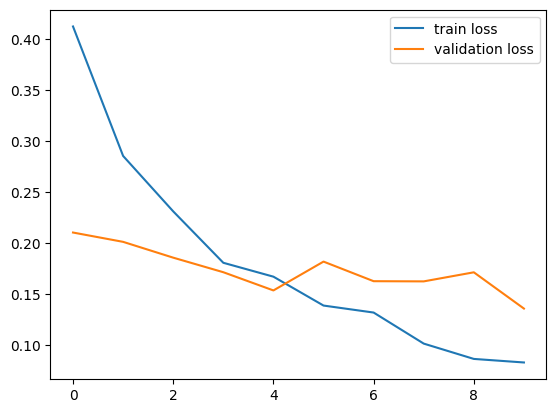

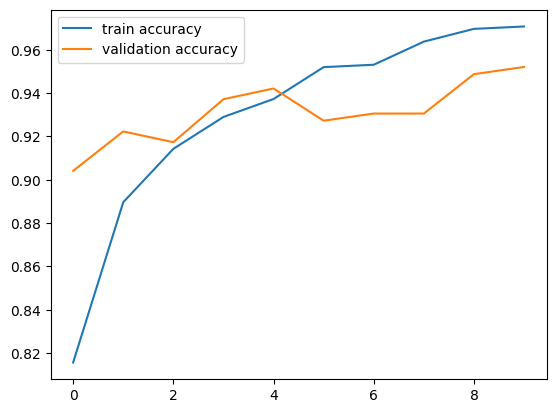

In [37]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

**Predictive System**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


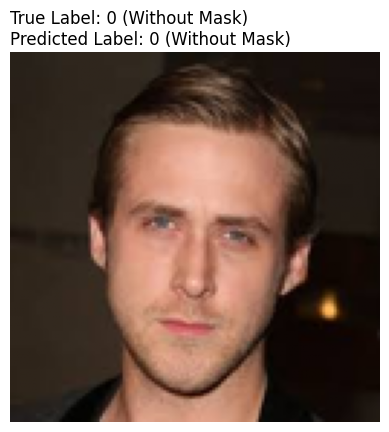

In [38]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Get a random index from the test dataset
random_index = random.randint(0, len(X_test_scaled) - 1)

# Get the image and its true label
random_image = X_test_scaled[random_index]
true_label = Y_test[random_index]

# Reshape the image for prediction (add a batch dimension)
input_image_for_prediction = np.expand_dims(random_image, axis=0)

# Make prediction
prediction = model.predict(input_image_for_prediction)
predicted_label = np.argmax(prediction)

# Define labels for display
label_names = {0: 'Without Mask', 1: 'With Mask'}

# Display the image
plt.imshow(random_image)
plt.title(f"True Label: {true_label} ({label_names[true_label]})\nPredicted Label: {predicted_label} ({label_names[predicted_label]})", loc='left')
plt.axis('off')
plt.show()
